<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Blood Pressure

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the blood pressure dataset
df = pd.read_csv('data/blood_pressure.csv')

# Quick check
print(df.shape)   # rows, columns
print(df.columns) # column names
df.head()

(721, 8)
Index(['user_code', 'measurement_datetime', 'diastolic', 'systolic',
       'functional_changes_index', 'circulatory_efficiency',
       'kerdo_vegetation_index', 'robinson_index'],
      dtype='object')


,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.4
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.0


## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [3]:
# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")


Data Structure
---------------
Dimensions: (721, 8)
Data Types:
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object
Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64


## Interpretation

This indicates that there are 721 observations (samples) of blood pressure, with each observation having 8 feature measurements.

The categorical features represent the user features (user_code, measurement_datetime), while the numerical features represent the measurements of the blood pressure (diastolic, systolic, functional_changes_index, circulatory_efficiency, kerdo_vegetation_index, robinson_index).

The dataset is incomplete, there are 422 missing values in functional_changes_index, circulatory_efficiency, robinson_index, and 438 missing values in kerdo_vegetation_index.

## Handling Missing Values

Several derived indices (functional_changes_index, circulatory_efficiency, kerdo_vegetation_index, robinson_index) have more than 50% missing values. 
Possible strategies:
- Drop columns with excessive missingness (> 50%) if they are unreliable.
- Imputation: For moderately missing columns (< 30%), we can use median (for robustness) or mean.
- Since these indices are derived from systolic/diastolic values, dropping them may still leave us with the core measurements.

**Choice:**  
Because > 50% of the values are missing, I will drop these derived indices to avoid bias from imputation. For smaller missingness, I would use median imputation.


In [4]:
clean = df.copy()

# Drop columns with >50% missing
threshold = 0.5
drop_cols = [c for c in clean.columns if clean[c].isna().mean() > threshold]
print("Dropping columns:", drop_cols)

clean = clean.drop(columns=drop_cols)

# For other columns with smaller missingness (if any), fill with median
for c in clean.columns:
    if clean[c].isna().any():
        if clean[c].dtype.kind in "biufc":  # numeric
            clean[c] = clean[c].fillna(clean[c].median())
        else:
            clean[c] = clean[c].fillna(clean[c].mode().iloc[0])


Dropping columns: ['functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']


In [ ]:
clean.isna().sum() # should be zero now

user_code               0
measurement_datetime    0
diastolic               0
systolic                0
dtype: int64

In [6]:
dup_count = clean.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

# Remove duplicates
clean = clean.drop_duplicates()


Number of duplicate rows: 0


## Interpretation
There are no duplicates in the dataset, no need further processing.

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [ ]:
df = clean
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df[numeric_columns].skew())
print(df[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
      diastolic    systolic
mean  81.228849  119.441054
50%   82.000000  120.000000

Dispersion Measures:
      diastolic    systolic
std    8.865761   10.522578
min   25.000000   63.000000
max  101.000000  157.000000

Distribution Measures:
------------------------
diastolic   -1.060136
systolic    -0.101898
dtype: float64
diastolic    3.050401
systolic     1.917806
dtype: float64


## Interpretation

### Descriptive Statistics
The mean systolic pressure is about 119.4 mmHg and the median is 120 mmHg, which are very close, suggesting a fairly symmetric distribution.  
The mean diastolic pressure is about 81.2 mmHg and the median is 82 mmHg, also very close, indicating a balanced distribution without major skew.

### Dispersion Measures
The standard deviation of systolic pressure is around 10.5 mmHg, while that of diastolic pressure is about 8.9 mmHg. These values show that most measurements are spread within a moderate range around their means.  
The observed minimums (63 systolic, 25 diastolic) and maximums (157 systolic, 101 diastolic) suggest the presence of potential extreme values that may require further outlier analysis.

### Distribution Measures
The skewness of systolic pressure is close to 0 (-0.10), indicating near symmetry, while diastolic has a slightly negative skew (-1.06), showing a small shift toward lower values.  
The kurtosis of systolic (1.92) and diastolic (3.05) are higher than 0, meaning the distributions are somewhat heavier-tailed than a normal distribution, with diastolic being more pronounced.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [9]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                       most_frequent_value
user_code                       a1c2e6b2eb
measurement_datetime  2020-05-11  00:27:56
diastolic                               80
systolic                               122


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.


Inconsistent Values: Most frequent values for each column. This helps identify any potential inconsistencies or anomalies. For example, if an unusually high frequency is observed for a specific value, it might indicate an issue with data collection or entry.

In [10]:
for col in ["diastolic", "systolic"]:
    mode_val = df[col].mode()[0]              # 众数（最常见值）
    freq = (df[col] == mode_val).sum()        # 出现次数
    perc = freq / len(df) * 100               # 百分比
    print(f"{col}: most frequent = {mode_val}, count = {freq}, percentage = {perc:.2f}%")


diastolic: most frequent = 80, count = 45, percentage = 6.24%
systolic: most frequent = 122, count = 55, percentage = 7.63%


## Interpretation

The most frequent values were examined for each column to check for potential inconsistencies.  
- For diastolic, the most frequent value is 80, appearing 45 times (6.24%).  
- For systolic, the most frequent value is 122, appearing 55 times (7.63%).  

Since both percentages are well below 20%, these values can be considered normal and representative of common blood pressure levels. 


## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?


Variable Relationships
----------------------
Correlation Matrix:
           diastolic  systolic
diastolic   1.000000  0.581326
systolic    0.581326  1.000000


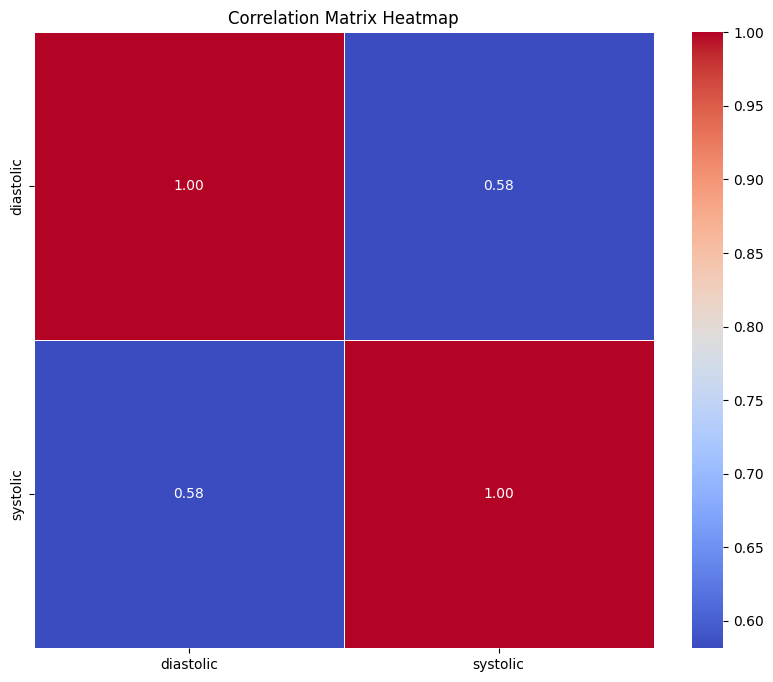

In [11]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Interpretation

Positive correlation values (close to 1) indicate a strong direct relationship, while negative values (close to -1) indicate an inverse relationship.
For example, diastolic and systolic have a moderate positive correlation (0.58). This means that individuals with higher diastolic pressure also tend to have higher systolic pressure. 

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


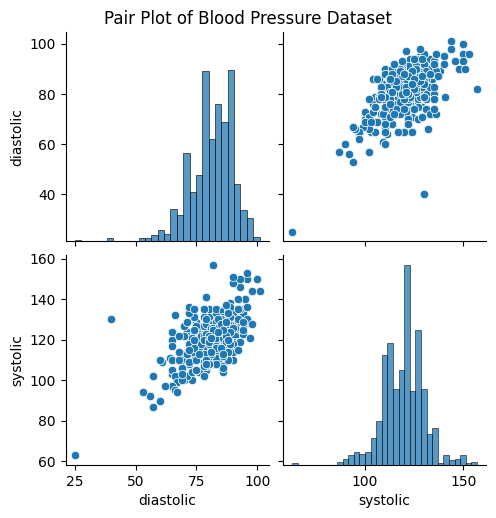

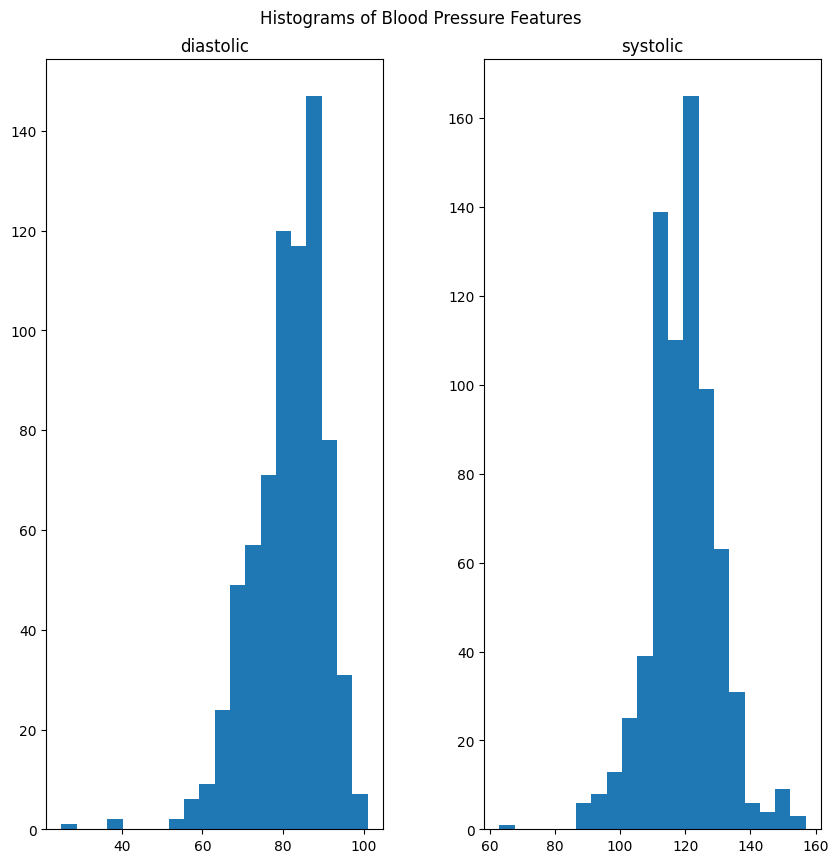

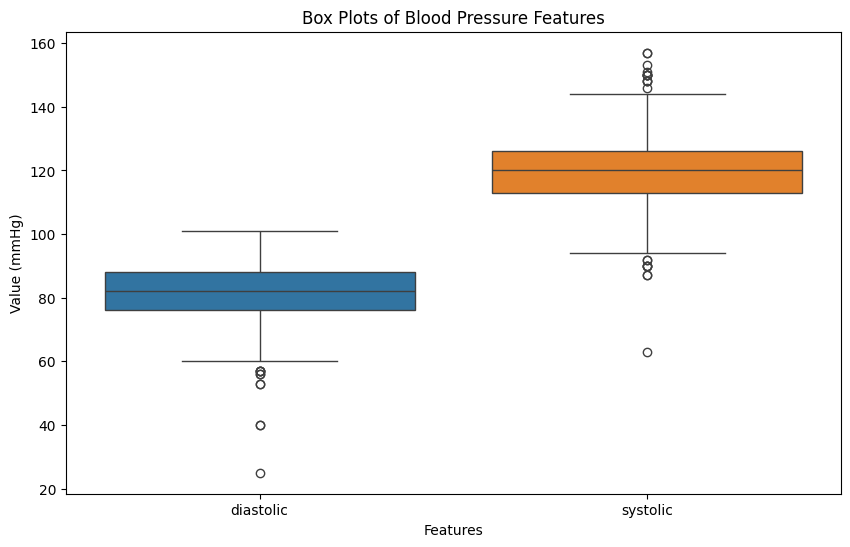

In [14]:
# Pair plot of numeric columns
sns.pairplot(df[numeric_columns])
plt.suptitle('Pair Plot of Blood Pressure Dataset', y=1.02)
plt.show()

# Visualize distributions
df[numeric_columns].hist(bins=20, figsize=(10,10), grid=False)
plt.suptitle('Histograms of Blood Pressure Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plots of Blood Pressure Features')
plt.xlabel('Features')
plt.ylabel('Value (mmHg)')
plt.show()

## Interpretation

#### Pair Plot:

The pair plot shows the relationship between diastolic and systolic blood pressure. A clear positive trend is observed: as diastolic increases, systolic also tends to increase. This aligns with medical expectations that these two measures of blood pressure are correlated. A few scattered points at the extremes suggest possible outliers.


#### Histograms:

The histograms display the distribution of each variable. Both diastolic and systolic pressures show approximately bell-shaped distributions centered around their means (about 81 mmHg and 119 mmHg respectively). This suggests that most values fall within a normal physiological range, with only a small number of extreme values on the tails.

#### Box Plots:

The box plots highlight the spread of the data and the presence of outliers. For diastolic, most values lie between 75 and 85 mmHg, but there are a few unusually low readings (below 40 mmHg). For systolic, the majority of observations are between 110 and 130 mmHg, with several outliers above 150 mmHg and below 80 mmHg. 


## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?


In [ ]:
# Parse datetime features
df["measurement_dt"] = pd.to_datetime(df["measurement_datetime"], errors="coerce")
df["hour"] = df["measurement_dt"].dt.hour
df["dayofweek"] = df["measurement_dt"].dt.dayofweek  # 0=Mon ... 6=Sun
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# Pulse Pressure = Systolic - Diastolic
df["pulse_pressure"] = df["systolic"] - df["diastolic"]

# Mean Arterial Pressure 
# MAP ≈ Diastolic + (Systolic - Diastolic)/3
df["mean_arterial_pressure"] = df["diastolic"] + df["pulse_pressure"] / 3


In [18]:
# ===== Show what we just created =====
print("\nFeature Engineering")
print("-------------------")

new_cols = ["pulse_pressure", "mean_arterial_pressure", "hour", "dayofweek", "is_weekend"]
existing_cols = ["systolic", "diastolic", "measurement_datetime"]
present = [c for c in new_cols if c in df.columns]

print("New columns created:", present)
print("\nPreview (head):")
display(df[existing_cols + present].head())

print("\nDescriptive stats of engineered features:")
display(df[present].describe())



Feature Engineering
-------------------
New columns created: ['pulse_pressure', 'mean_arterial_pressure', 'hour', 'dayofweek', 'is_weekend']

Preview (head):


,systolic,diastolic,measurement_datetime,pulse_pressure,mean_arterial_pressure,hour,dayofweek,is_weekend
0,150,100,2020-04-29 22:33:33,50,116.666667,22,2,0
1,150,100,2020-04-30 01:33:33,50,116.666667,1,3,0
2,140,95,2020-04-30 09:16:38,45,110.000000,9,3,0
3,140,95,2020-04-30 12:16:38,45,110.000000,12,3,0
4,130,80,2020-05-01 06:58:06,50,96.666667,6,4,0



Descriptive stats of engineered features:


,pulse_pressure,mean_arterial_pressure,hour,dayofweek,is_weekend
count,721.000000,721.000000,721.000000,721.000000,721.000000
mean,38.212205,93.966251,12.291262,3.091540,0.303745
std,8.992322,8.446305,5.789458,2.042588,0.460193
min,18.000000,37.666667,0.000000,0.000000,0.000000
25%,31.000000,89.333333,8.000000,1.000000,0.000000
50%,38.000000,94.333333,11.000000,3.000000,0.000000
75%,43.000000,99.333333,17.000000,5.000000,1.000000
max,90.000000,116.666667,23.000000,6.000000,1.000000


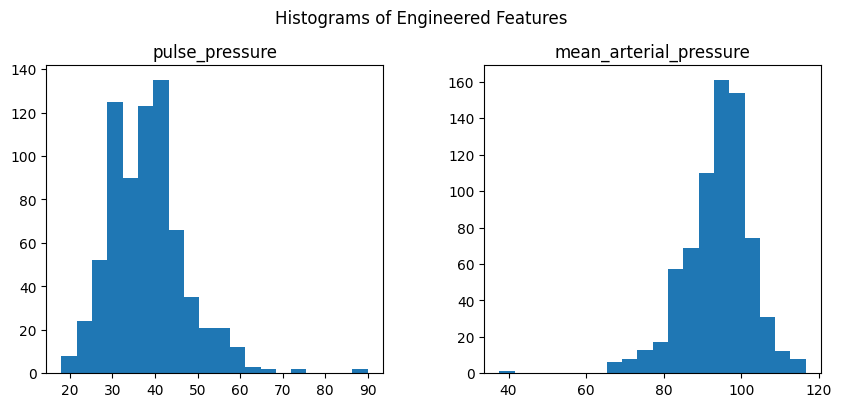

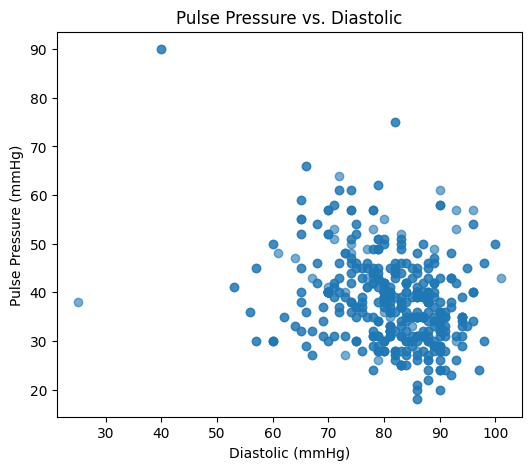

In [19]:
# Histograms for engineered features
ax = df[["pulse_pressure","mean_arterial_pressure"]].hist(bins=20, figsize=(10,4), grid=False)
plt.suptitle("Histograms of Engineered Features", y=1.02)
plt.show()

# Scatter to see relation with originals
plt.figure(figsize=(6,5))
plt.scatter(df["diastolic"], df["pulse_pressure"], alpha=0.6)
plt.xlabel("Diastolic (mmHg)")
plt.ylabel("Pulse Pressure (mmHg)")
plt.title("Pulse Pressure vs. Diastolic")
plt.show()


## Interpretation

#### New Features (Pulse Pressure and Mean Arterial Pressure):

Pulse Pressure is a known cardiovascular risk marker: higher values may signal arterial stiffness or heart disease risk.

Mean Arterial Pressure (MAP) is significant because it reflects the average blood pressure in arteries, and values too low (< 60 mmHg) or too high (> 110 mmHg) can indicate circulatory problems.

### Histograms
The histogram of pulse pressure shows a roughly normal distribution centered around 38 mmHg, with most values falling between 30 and 45 mmHg. This indicates that the majority of individuals have a moderate difference between systolic and diastolic pressures.

The histogram of mean arterial pressure (MAP) is also approximately normal, centered around 94 mmHg. This aligns with typical clinical ranges, where MAP values between 70–100 mmHg are considered normal.

### Scatter Plot: Pulse Pressure vs. Diastolic
The scatter plot reveals that pulse pressure does not have a strong linear relationship with diastolic pressure. Instead, points are spread widely across the range, meaning individuals with the same diastolic pressure may have very different pulse pressures.